# Experiment No 7

## Aim:
To build Bagging, Boosting, and Stacking ensemble classification models on the Glass Identification dataset and evaluate their performance using appropriate metrics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load Glass dataset
glass = fetch_ucirepo(id=42)

# Create dataframe
df = pd.concat([glass.data.features, glass.data.targets], axis=1)

print("Dataset loaded")
df.head()

Dataset loaded


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Preprocessing

In [4]:
# Separate features and target
X_data = df.drop(columns=['Type_of_glass'])
y_data = df['Type_of_glass']

# Encode target (multiclass)
encoder = LabelEncoder()
y_data = encoder.fit_transform(y_data)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Bagging – Random Forest

In [5]:
bag = RandomForestClassifier(n_estimators=100, random_state=42)

bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

metrics_bag = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_bag)],
    'Precision': [precision_score(y_test, y_pred_bag, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_bag, average='weighted')],
    'F1-Score':  [f1_score(y_test, y_pred_bag, average='weighted')]
}).round(4)

display(metrics_bag)
print(classification_report(y_test, y_pred_bag))

,Accuracy,Precision,Recall,F1-Score
0,0.8372,0.8542,0.8372,0.8355


              precision    recall  f1-score   support

           0       0.76      0.93      0.84        14
           1       0.85      0.73      0.79        15
           2       1.00      0.67      0.80         3
           3       1.00      0.67      0.80         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43



## Confusion Matrix – Random Forest

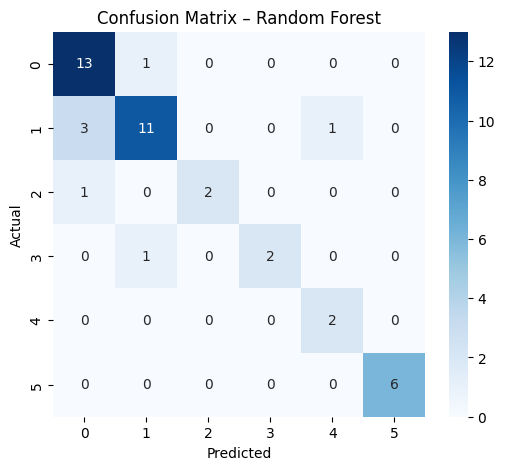

In [6]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_bag),
            annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix – Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Boosting – AdaBoost & Gradient Boosting

In [7]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

metrics_boost = pd.DataFrame({
    'Model':     ['AdaBoost', 'Gradient Boosting'],
    'Accuracy':  [accuracy_score(y_test, y_pred_ada),  accuracy_score(y_test, y_pred_gb)],
    'Precision': [precision_score(y_test, y_pred_ada, average='weighted'),
                  precision_score(y_test, y_pred_gb, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_ada, average='weighted'),
                  recall_score(y_test, y_pred_gb, average='weighted')],
    'F1-Score':  [f1_score(y_test, y_pred_ada, average='weighted'),
                  f1_score(y_test, y_pred_gb, average='weighted')]
}).round(4)

display(metrics_boost)

,Model,Accuracy,Precision,Recall,F1-Score
0,AdaBoost,0.3953,0.4667,0.3953,0.3638
1,Gradient Boosting,0.8372,0.8491,0.8372,0.8355


## Confusion Matrices – Boosting

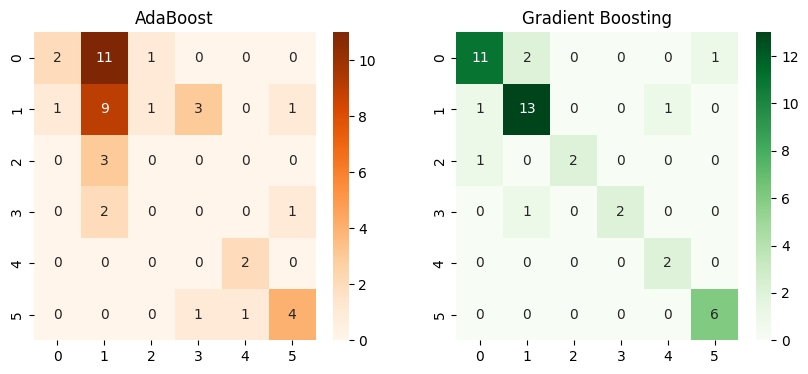

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(confusion_matrix(y_test, y_pred_ada),
            annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('AdaBoost')

sns.heatmap(confusion_matrix(y_test, y_pred_gb),
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Gradient Boosting')

plt.show()

## Stacking

In [9]:
base_learners = [
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('nb',  GaussianNB())
]

meta_learner = LogisticRegression(max_iter=1000)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

stack.fit(X_train_scaled, y_train)

y_pred_stack = stack.predict(X_test_scaled)

metrics_stack = pd.DataFrame({
    'Accuracy':  [accuracy_score(y_test, y_pred_stack)],
    'Precision': [precision_score(y_test, y_pred_stack, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_stack, average='weighted')],
    'F1-Score':  [f1_score(y_test, y_pred_stack, average='weighted')]
}).round(4)

display(metrics_stack)

print(classification_report(y_test, y_pred_stack))

c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Accuracy,Precision,Recall,F1-Score
0,0.6744,0.6417,0.6744,0.653


              precision    recall  f1-score   support

           0       0.77      0.71      0.74        14
           1       0.59      0.67      0.62        15
           2       0.00      0.00      0.00         3
           3       0.67      0.67      0.67         3
           4       0.50      1.00      0.67         2
           5       0.83      0.83      0.83         6

    accuracy                           0.67        43
   macro avg       0.56      0.65      0.59        43
weighted avg       0.64      0.67      0.65        43



c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Manasveer\Desktop\ML_LAB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

## Confusion Matrix – Stacking

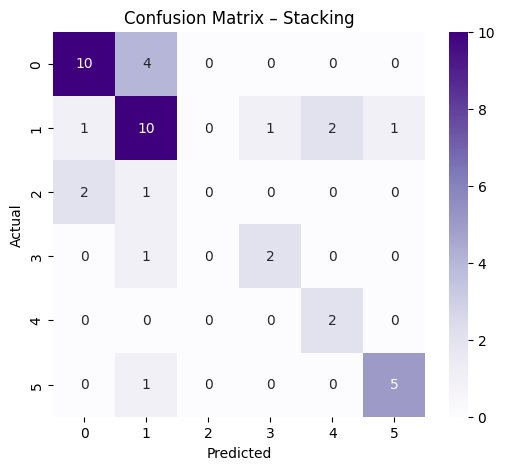

In [10]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_stack),
            annot=True, fmt='d', cmap='Purples')

plt.title('Confusion Matrix – Stacking')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Conclusion

Ensemble methods improve performance on the Glass Identification dataset. Random Forest reduces variance, Boosting methods improve learning by correcting errors, and Stacking combines multiple models to achieve better overall classification performance in multiclass problems.